a)Проверить переменные ξk на мультиколлинеарность

In [2]:
import numpy as np
np.random.seed(42)

n = 50

xi = np.random.uniform(-1, 1, (n, 5))
x1, x2, x3, x4, x5 = xi[:, 0], xi[:, 1], xi[:, 2], xi[:, 3], xi[:, 4]

eta = np.random.normal((2 + 3*x1 - 2*x2 + x3 + x4 -x5), 1.5 ** 2, 50) 
#здесь на параметр loc подается вектор размером 50, но np может так работать
#потому что в таком случае он просто считает для каждого элементра свое среднее 
#и по этим параметрам берет число из распределения
#eta[0] ~ N(loc[0], σ), ...
print(xi[:5])
print(" ")
print(eta[:5])


[[-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]
 [-0.68801096 -0.88383278  0.73235229  0.20223002  0.41614516]
 [-0.95883101  0.9398197   0.66488528 -0.57532178 -0.63635007]
 [-0.63319098 -0.39151551  0.04951286 -0.13610996 -0.41754172]
 [ 0.22370579 -0.72101228 -0.4157107  -0.26727631 -0.08786003]]
 
[-1.11163481 -1.18633642 -3.03487752  3.14129999  3.99972587]


In [ ]:
ones = np.ones((n, 1))
for i in range(5):
    x_others = np.delete(xi, i, 1)
    psi = np.hstack((ones, x_others))
    

    F = psi.T @ psi#(5,5)

    F_inv = np.linalg.inv(F)

    beta =  F_inv @psi.T @ xi[:, i]
    print(f"beta = {beta}")

    e = xi[:, i] - psi @ beta
    RSS = e.T @ e
    TSS = np.sum((xi[:, i] - xi[:, i].mean()) ** 2)
    R2 = (TSS- RSS) / TSS
    print(f"{R2} меньше 0.7 -> нет мультиколлинеарности") if R2 < 0.7 else print("есть мультиколлинеарность") 
    print(" ")



beta = [ 0.01205677 -0.08691022 -0.30793044 -0.00750011 -0.05014611]
0.11716704972075957 меньше 0.7 -> нет мультиколлинеарности
 
beta = [-0.05873019 -0.08260467  0.18710328  0.07570786 -0.24379981]
0.11394500042647829 меньше 0.7 -> нет мультиколлинеарности
 
beta = [ 0.04373099 -0.30743626  0.19653962 -0.0386505   0.04767926]
0.14291306571296566 меньше 0.7 -> нет мультиколлинеарности
 
beta = [ 0.00194092 -0.00845104  0.08975316 -0.04362096  0.22316747]
0.04607383569589297 меньше 0.7 -> нет мультиколлинеарности
 
beta = [-0.08606186 -0.0502528  -0.25705299  0.04785751  0.19847758]
0.10000410062180637 меньше 0.7 -> нет мультиколлинеарности
 


Провеили по всем переменным, нет мультиколлинеарности. 

б) Определить уравнение линейной регрессии и проверить значимость коэффициентов

In [56]:
from scipy import stats 

p = 6 #пять переменных + константа 
psi = np.hstack((ones, xi))
F = psi.T @ psi
F_inv = np.linalg.inv(F)
beta = F_inv @ psi.T @ eta

print(f"beta = {beta}")

beta = [ 2.10485662  2.63275459 -2.21138066  1.01442407  0.65252894 -1.31573333]


In [58]:
RSS = e.T @ e
TSS = np.sum((eta - eta.mean()) ** 2) #полный разброс того, что предсказываем 

for i in range(6):
    e = eta - psi @ beta

    delta = beta[i]/ (np.sqrt(F_inv[i, i] * RSS)) * np.sqrt(n - p)
    p_value = 2 * (1 - stats.t.cdf(abs(delta), df = n-p)) # 1 - функция распределения = P( > delta)

    print(p_value)

9.678327368423112e-07
0.0002200803105862903
0.0019370071682183188
0.1282457588775563
0.29520832195384816
0.05009829071469096


получается b3, b4, b5 отвергаем при уровне значимости = 0.05 
причина, скорее всего, недостаточная мощность критерия. 

с) Определить коэффициент детерминации и проверить его на значимость 

In [61]:
R2_full = (TSS - RSS) / TSS

delta = ((TSS - RSS) / RSS)* ((n - p) / (p - 1))
p_value = 1 - stats.f.cdf(delta, p-1, n-p) # 1 - функция распределения = P( > delta)

print(R2_full)
print(p_value)

0.4203920448022693
0.0001544428439378409


d) Найти значение в точке xk = 0 и построить 95% доверительный иннтервал.

In [ ]:
psi0 = np.array([1, 0, 0, 0, 0, 0])
y0 = psi0@ beta # beta[0]

t_crit = stats.t.ppf(0.975, df = n-p)

delta = t_crit * np.sqrt(RSS * (1 + psi0 @ F_inv @ psi0.T)/ (n-p))

print(f"Прогноз: {y0}")
print(f"Доверительный интервал: ({y0 - delta}, {y0 + delta})")

Прогноз: 2.104856615965944
Доверительный интервал: (-3.1347433945057963, 7.344456626437684)


e) Проверить предположение о независимости ошибок измерения. 

In [ ]:
def count_inversions(arr):
    count = 0
    for i in range(len(arr)):
        for j in range(i+1, len(arr)):
            if arr[i] > arr[j]:
                count += 1
    
    return count 




In [ ]:
e = eta - psi @ beta
delta = (count_inversions(e) - (n* (n-1)/4)) / np.sqrt( n**3 / 36)
p_value = 2 * stats.norm.cdf(delta, loc=0, scale=1)

print(p_value)

0.569686102562576


f) Проверить предположение о нормальности распределения ошибок

In [26]:
sigma2 = RSS / (n-p) 

e_sorted = np.sort(e)
F_emp_r = np.arange(1, n+1) / n
F_emp_l = np.arange(0, n) / n

F_theor = stats.norm.cdf(e_sorted, loc=0, scale=np.sqrt(sigma2))

sup = np.max(np.maximum(
    np.abs(F_emp_r - F_theor),
    np.abs(F_emp_l  - F_theor)
))

delta_true = np.sqrt(n) * sup 

print(delta_true)

np.random.seed(42)
delta_ = []
for i in range(50000):
    e_stat = np.random.normal(loc=0, scale=np.sqrt(sigma2), size=n)
    e_stat_sorted = np.sort(e_stat)

    #эмперическая функция распределения выглядит также, потому что зависит только от n
    F_theor = stats.norm.cdf(e_stat_sorted, loc=0, scale=np.sqrt(sigma2))
    
    sup_stat = np.max(np.maximum(
        np.abs(F_theor - F_emp_l),
        np.abs(F_theor - F_emp_r)
    ))

    delta_.append(np.sqrt(n) * sup_stat)

p_value = np.mean(np.array(delta_) >= delta_true)
print(p_value)




0.8701336739997103
0.40168


Ошибки распределены нормально. Это ожидаемо — мы сами генерировали ε ~ N(0, 1.5²).

g) Исследовать регрессию на выбросы. 

Число выбросов: 1


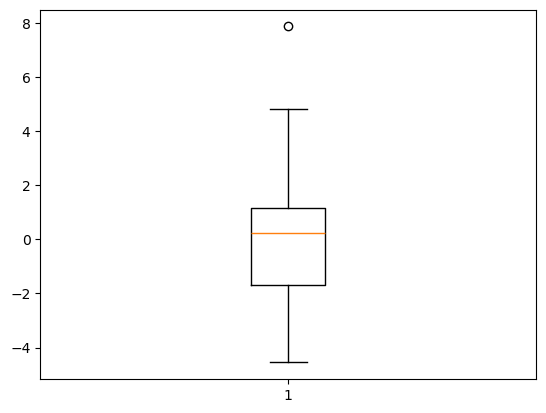

In [ ]:
import matplotlib.pyplot as plt
q1 = np.percentile(e, 25)
q3 = np.percentile(e, 75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

out = e[(e < lower) | (e > upper)]  

print(f"Число выбросов: {len(out)}")

plt.boxplot(e)
plt.show()


h) Провести кросс-проверку регрессии. 

In [34]:
CVSS = 0

for i in range(n):
    #убираем i-ое наблюдение
    psi_train = np.delete(psi, i, axis=0)
    eta_train = np.delete(eta, i)

    F_train = psi_train.T @ psi_train
    F_train_inv = np.linalg.inv(F_train)
    beta = F_train_inv @ psi_train.T @ eta_train
    
    y_pred = psi[i] @ beta

    CVSS += (eta[i] - y_pred) ** 2

R2_CV = (TSS - CVSS) / TSS
print(R2_CV)

0.2568380854845508


i) Проверить адекватность регрессии, сделав 5 повторных измерений в одной точке.

In [36]:
l = 5
x0 = np.array([0, 0, 0, 0, 0])
y_repeat = np.random.normal(2 + 3*x0[0] - 2*x0[1] + x0[2] + x0[3] - x0[4], 1.5, l)

sigma1_2 = np.sum((y_repeat - y_repeat.mean()) ** 2) / l-1 #делим на l-1 а не на l потому что это несмещенная оценка дисперсии

print(sigma1_2)

delta = RSS / (n-p) * (1/ sigma1_2)
p_value = 1 - stats.f.cdf(delta, n-p, l-1)

print(p_value)



0.389780653072622
0.0066537923271973165


j) Удалить переменную, соотвествующую наименее значимому коэффициенту регрессии и повторить пункты b и с, сравнить уравнения регрессии. 

In [62]:
psi_new = np.delete(psi, 4, axis=1)# четвертый столбец, самый большой p-value из пункта b
p_new = 5 #новаая размерность

F_new = psi_new.T @ psi_new
F_new_inv = np.linalg.inv(F_new)
beta_new = F_new_inv @ psi_new.T @ eta

print(beta_new)

TSS = np.sum((eta - eta.mean()) ** 2)
e = eta - psi_new @ beta_new
RSS = e.T @ e

R2_new = (TSS - RSS) / TSS

print(R2_new)

for i in range(p_new):
    delta = beta_new[i] / (np.sqrt(F_new_inv[i, i] * RSS)) * np.sqrt(n - p_new)
    p_value = 2 * (1 - stats.t.cdf(abs(delta), df=n-p_new))
    print(f"beta_{i}: p-value = {p_value}")






[ 2.10612312  2.62724004 -2.15281413  0.98596014 -1.1701101 ]
0.4056083029856239
beta_0: p-value = 9.180185351898018e-07
beta_1: p-value = 0.0002241109883622805
beta_2: p-value = 0.002404844601214373
beta_3: p-value = 0.1390612739412196
beta_4: p-value = 0.07386842296821583


k) Сравнить уравнения регрессии бутстрапом

In [64]:
h_obs = R2_full - R2_new
N = 1000
delta_boot = []
for i in range(N):
    idx = np.random.choice(n, size=n, replace=True)
    psi_boot = psi[idx]
    eta_boot = eta[idx]

    #full
    F_b = psi_boot.T @ psi_boot
    F_b_inv = np.linalg.inv(F_b)
    beta_b_full = F_b_inv @ psi_boot.T @ eta_boot
    e_b_full = eta_boot - psi_boot @ beta_b_full
    TSS_b = np.sum((eta_boot - np.mean(eta_boot)) ** 2) 
    RSS_b = e_b_full.T @ e_b_full
    R2_b_full = (TSS_b - RSS_b) / TSS_b

    #new (без e4)
    psi_new_boot = np.delete(psi_boot, 4, axis=1)
    F_b_new = psi_new_boot.T @ psi_new_boot
    F_b_new_inv  = np.linalg.inv(F_b_new)
    beta_b_new = F_b_new_inv @ psi_new_boot.T @ eta_boot
    e_b_new = eta_boot - psi_new_boot @ beta_b_new
    RSS_b_new = e_b_new.T @ e_b_new
    R2_b_new = (TSS_b - RSS_b_new) / TSS_b

    delta_boot.append(R2_b_full - R2_b_new - h_obs)


delta_sorted = np.sort(delta_boot)
k1 = int(0.025 * N)
k2 = int(0.975 * N)

low = h_obs - delta_sorted[k2]
high = h_obs - delta_sorted[k1]

print(f"Доверительный интервал: ({low}, {high})")




Доверительный интервал: (-0.08044380475633628, 0.02954043121144284)
